In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

df = pd.read_csv("webapp/Mall_Customers.csv")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [32]:
# Preprocessing
df.drop(columns=['CustomerID','Age','Gender'], inplace=True)

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df)

In [33]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


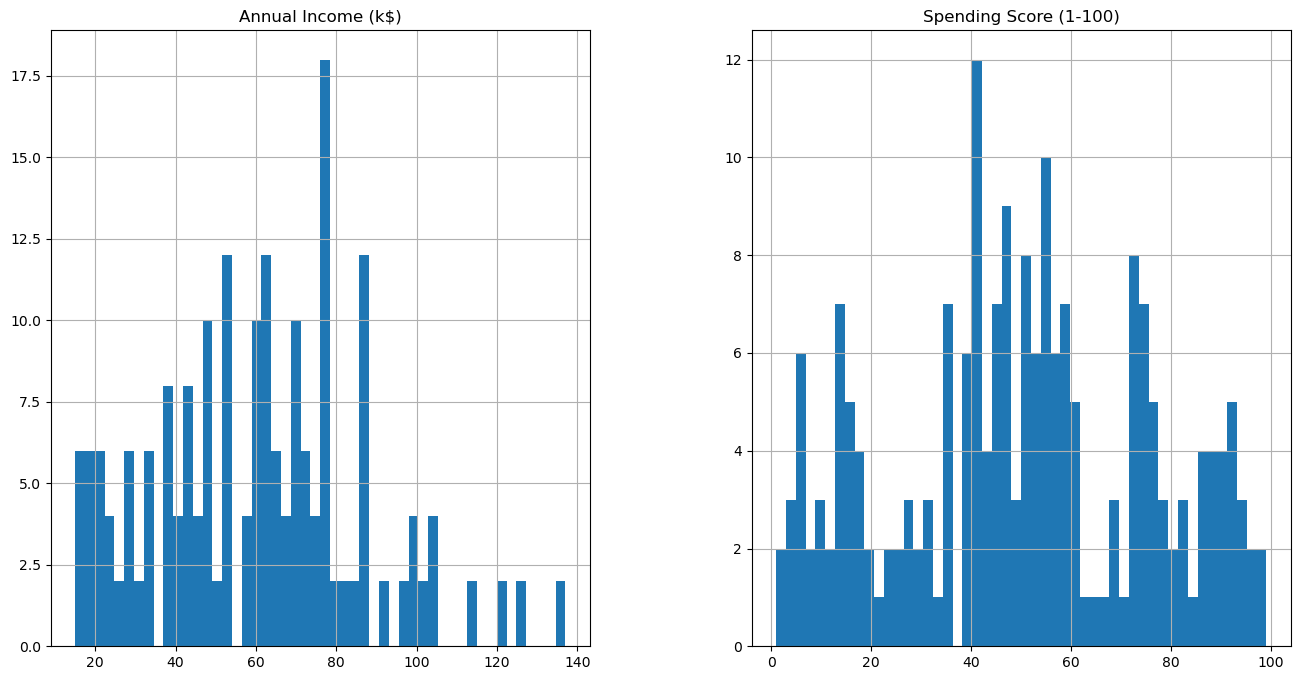

In [34]:
df.hist(bins = 50, figsize = (16, 8))
plt.show()

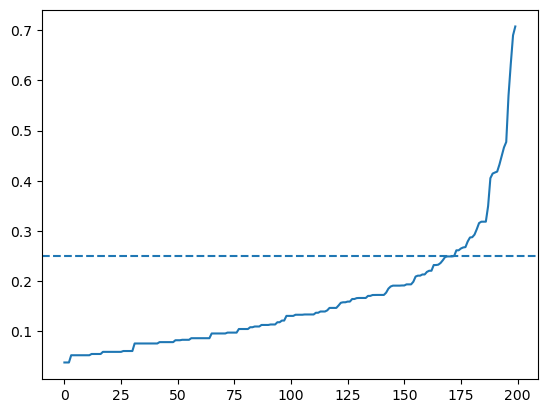

In [35]:
neighbours = NearestNeighbors(n_neighbors=4)
nbrs = neighbours.fit(df_scaled)
dis, ind = nbrs.kneighbors(df_scaled)

dis = np.sort(dis[:,-1])
plt.plot(dis)
plt.axhline(y=0.25, linestyle='--')

Silhouette Score: 0.43068698880669604


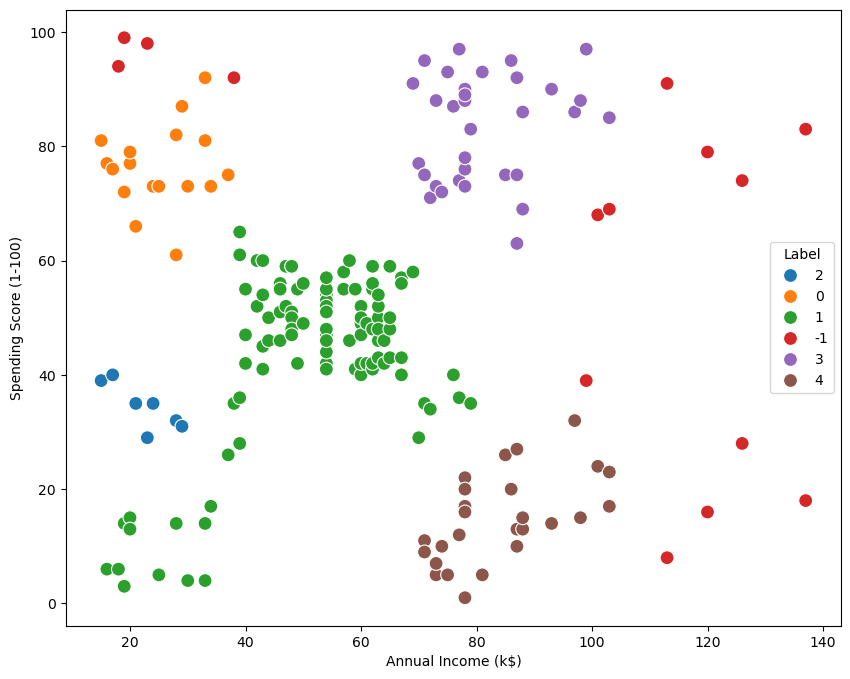

In [36]:
cluster = DBSCAN(eps = 0.25, min_samples=4)
df['Label'] = cluster.fit_predict(df_scaled).astype(str)

labels = cluster.fit_predict(df_scaled)
mask = labels != -1
if len(set(labels[mask])) > 1:
    score = silhouette_score(df_scaled[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters to compute silhouette score")

plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = df, hue = 'Label', palette = 'tab10', s=100)
plt.show()

Silhouette Score: 0.5553744823146946


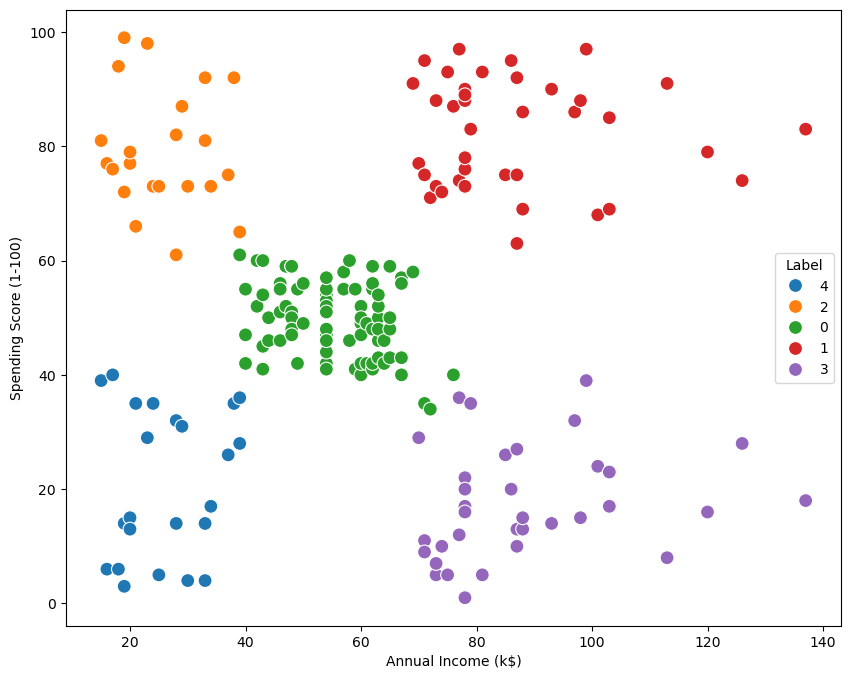

In [37]:
kmeans = KMeans(n_clusters=5, random_state = 42)
df['Label'] = kmeans.fit_predict(df).astype(str)

labels = kmeans.fit_predict(df)
score = silhouette_score(df, labels)
print("Silhouette Score:", score)

plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = df, hue = 'Label', palette = 'tab10', s=100)
plt.show()


Silhouette Score: 0.33440074394139574


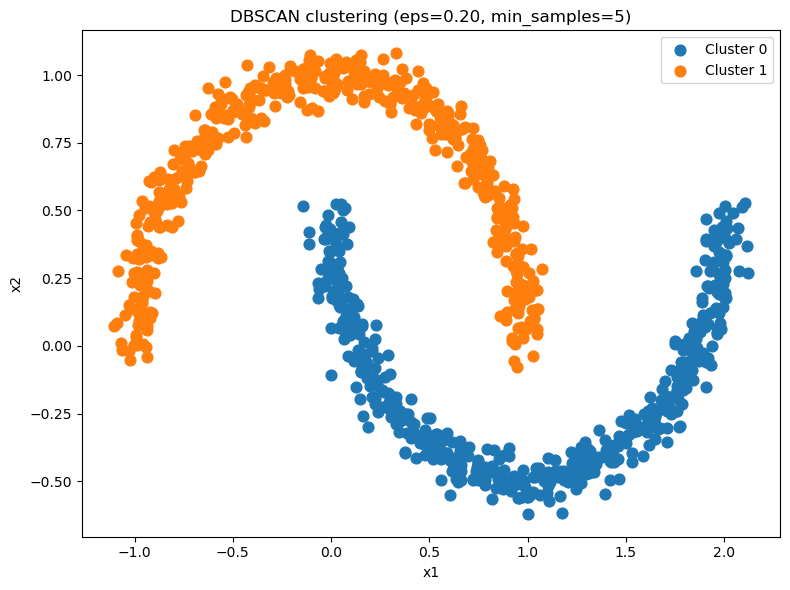

In [38]:
X, y = make_moons(n_samples=1000, noise = 0.05, random_state=42)
dbscan = DBSCAN(eps = 0.2, min_samples=5)
labels = dbscan.fit_predict(X)

mask = labels != -1
if len(set(labels[mask])) > 1:
    score = silhouette_score(X[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters to compute silhouette score")


fig, ax = plt.subplots(figsize=(8,6))

for label in sorted(set(labels)):
    mask = labels == label
    if label == -1:
        ax.scatter(X[mask,0], X[mask,1], c='red',marker='x', s=40, linewidths=1.2, label='Noise')
    else:
        ax.scatter(X[mask, 0], X[mask, 1], s=60, label=f'Cluster {label}')

ax.set_title('DBSCAN clustering (eps=0.20, min_samples=5)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()
plt.tight_layout()
plt.show()



Silhouette Score: 0.4887268471194725


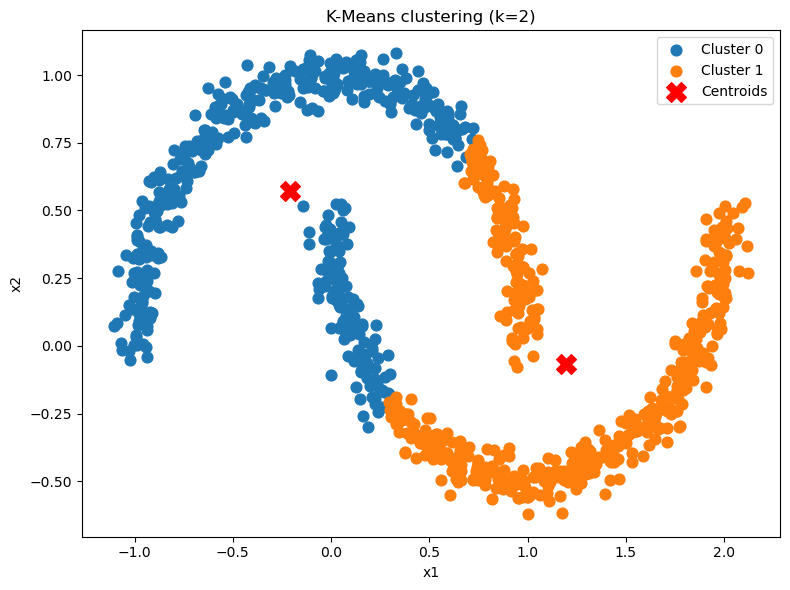

In [39]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

fig, ax = plt.subplots(figsize=(8, 6))

for label in sorted(set(labels)):
    mask = labels == label
    ax.scatter(X[mask, 0], X[mask, 1], s=60, label=f'Cluster {label}')

centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title('K-Means clustering (k=2)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()
plt.tight_layout()
plt.show()